# Housing prices

**Author** : Leslie LESAUVAGE 

**Date** : 5/10/2024

**Objective** : Predict the price of a house. 

Having chosen the Economics and Social Sciences major, I'm interested in this type of problem. This study will enable us to learn more about the American property market. The data set comes from Kaggle and has been created by M Yasser H, by collecting informations on Google. To achieve my objective, I used the variables that seemed most relevant and interesting to me, namely the surface area of the house, the number of bedrooms, bathrooms, parking spaces, floors, whether or not there is a basement, hot water, and whether the house is on the main road. 

## I - Library import and function construction

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.neural_network import MLPRegressor

In [65]:
def plot_sorted_coefficients(coef, threshold = 1e-08):

    # Sort the coefficients by their absolute values
    sorted_coef = coef.abs().sort_values()
    
    # Get the original coefficients for coloring
    original_sorted_coef = coef.loc[sorted_coef.index]
    
    # Create a scatter plot with bars
    plt.figure(figsize=(8, 7))
    
    # Plot positive coefficients in blue, negative coefficients in yellow, and near-zero coefficients in grey
    colors = [
        'grey' if abs(c) < threshold else 'green' if c > 0 else 'red'
        for c in original_sorted_coef
    ]
    
    # Scatter plot for coefficients
    plt.scatter(sorted_coef.values, sorted_coef.index, color = colors, zorder = 5)
    
    # Plot lines from the origin to the scatter points
    for i in range(len(sorted_coef)):
        plt.plot([0, sorted_coef.values[i]], [i, i], color = 'skyblue', lw = 2)
    
    # Add vertical line at zero
    plt.axvline(x = 0, color = 'gray', linestyle = '--', linewidth = 1)
    
    # Set labels and title
    plt.xlabel('Absolute Coefficient Value')
    plt.ylabel('Feature')
    plt.title('Fig. 3 Logistic Regression Coefficients (Absolute Values)')
    
    # Show the plot
    plt.show()

## II - Data import

In [66]:
df = pd.read_csv("housing_prices.csv")
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


## III - Data manipulation

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [68]:
#drop useless colunms
df = df.drop(['guestroom', 'airconditioning', 'prefarea', 'furnishingstatus'], axis = 1)
df

,price,area,bedrooms,bathrooms,stories,mainroad,basement,hotwaterheating,parking
0,13300000,7420,4,2,3,yes,no,no,2
1,12250000,8960,4,4,4,yes,no,no,3
2,12250000,9960,3,2,2,yes,yes,no,2
3,12215000,7500,4,2,2,yes,yes,no,3
4,11410000,7420,4,1,2,yes,yes,no,2
...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,yes,no,2
541,1767150,2400,3,1,1,no,no,no,0
542,1750000,3620,2,1,1,yes,no,no,0
543,1750000,2910,3,1,1,no,no,no,0


c:\Users\lesli\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Text(0.5, 0.98, 'Fig.1 Distribution of homes by price')

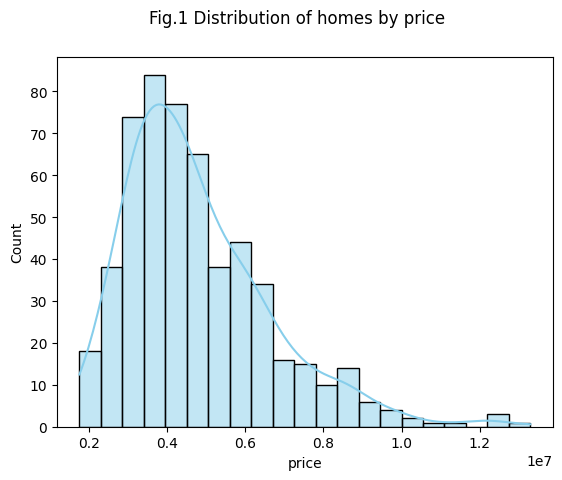

In [69]:
sns.histplot(df['price'], color='skyblue', kde=True)
plt.suptitle('Fig.1 Distribution of homes by price')

c:\Users\lesli\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


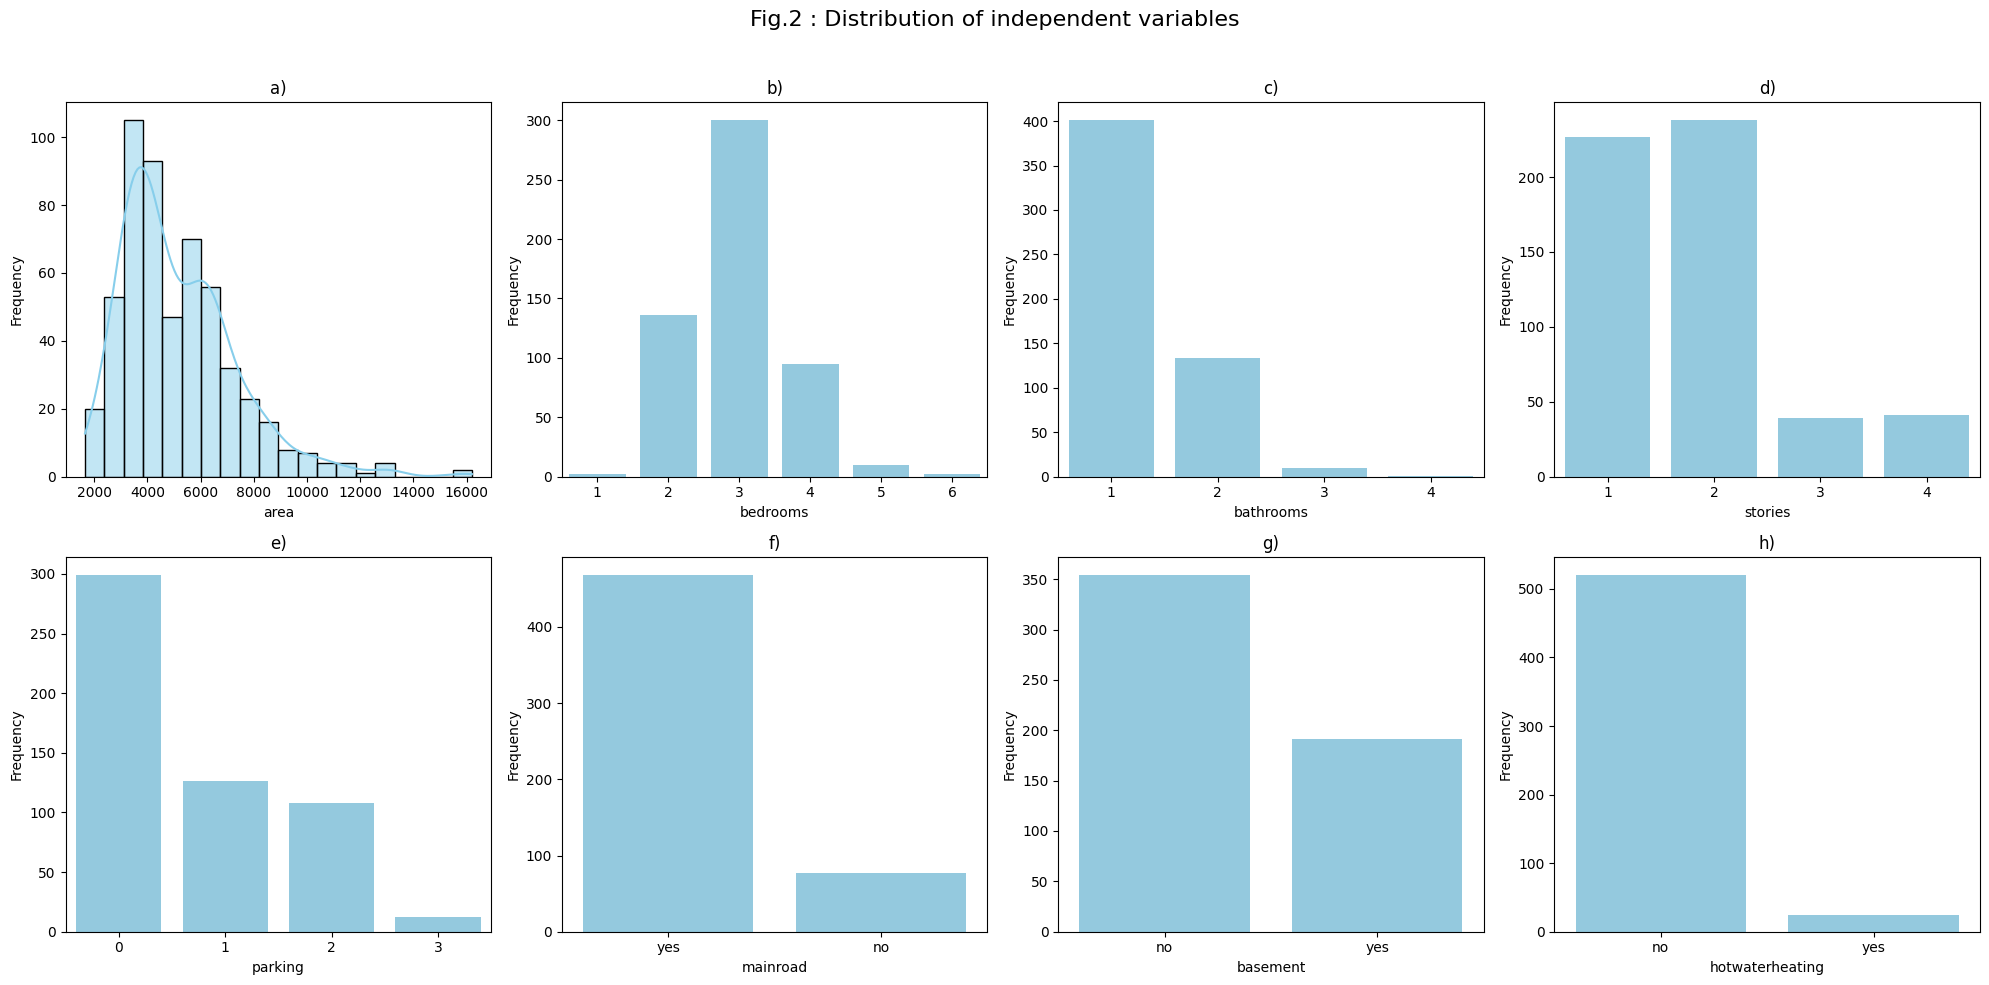

In [70]:
variables = ['area', 'bedrooms', 'bathrooms', 'stories', 
             'parking', 'mainroad', 'basement', 'hotwaterheating']

titles = ['a)', 'b)', 'c)', 'd)', 'e)', 'f)', 'g)', 'h)']

fig, axs = plt.subplots(2, 4, figsize=(20, 10))

for i, var in enumerate(variables):
    ax = axs[i // 4, i % 4]
    
    # Continuous variable 
    if var == 'area':
        sns.histplot(df[var], bins=20, kde=True, color='skyblue', ax=ax)
    
    # Ordinal variables
    elif var in ['bedrooms', 'bathrooms', 'stories', 'parking']:
        sns.countplot(x=df[var], color='skyblue', ax=ax)
    
    # Categorical variables 
    elif var in ['mainroad', 'basement', 'hotwaterheating']:
        sns.countplot(x=df[var], color='skyblue', ax=ax)
    
    ax.set_title(f'{titles[i]}')
    ax.set_xlabel(var)
    ax.set_ylabel('Frequency')

fig.suptitle('Fig.2 : Distribution of independent variables', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [71]:
# Transforming categorical variable
df['basement'] = df['basement'].map({'no': 0, 'yes': 1})
df['mainroad'] = df['mainroad'].map({'no': 0, 'yes': 1})
df['hotwaterheating'] = df['hotwaterheating'].map({'no': 0, 'yes': 1})

In [72]:
df = pd.get_dummies(df, columns = ['bedrooms'], drop_first = True)
df = pd.get_dummies(df, columns = ['bathrooms'], drop_first = True)
df = pd.get_dummies(df, columns = ['stories'], drop_first = True)
df = pd.get_dummies(df, columns = ['parking'], drop_first = True)

bool_cols = df.select_dtypes(include=[bool]).columns
df[bool_cols] = df[bool_cols].astype(int)

df

,price,area,mainroad,basement,hotwaterheating,bedrooms_2,bedrooms_3,bedrooms_4,bedrooms_5,bedrooms_6,bathrooms_2,bathrooms_3,bathrooms_4,stories_2,stories_3,stories_4,parking_1,parking_2,parking_3
0,13300000,7420,1,0,0,0,0,1,0,0,1,0,0,0,1,0,0,1,0
1,12250000,8960,1,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,1
2,12250000,9960,1,1,0,0,1,0,0,0,1,0,0,1,0,0,0,1,0
3,12215000,7500,1,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,1
4,11410000,7420,1,1,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0
541,1767150,2400,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
542,1750000,3620,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
543,1750000,2910,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0


# IV - Data normalisation

In [73]:
cols = [col for col in df.drop('price', axis = 1).columns]

scaler = StandardScaler()
df[cols] = pd.DataFrame(scaler.fit_transform(df[cols]), index = df.index)

df

,price,area,mainroad,basement,hotwaterheating,bedrooms_2,bedrooms_3,bedrooms_4,bedrooms_5,bedrooms_6,bathrooms_2,bathrooms_3,bathrooms_4,stories_2,stories_3,stories_4,parking_1,parking_2,parking_3
0,13300000,1.046726,0.405623,-0.734539,-0.219265,-0.576644,-1.106567,2.176429,-0.136717,-0.06069,1.760041,-0.136717,-0.042875,-0.880480,3.601994,-0.285218,-0.548376,2.011541,-0.150047
1,12250000,1.757010,0.405623,-0.734539,-0.219265,-0.576644,-1.106567,2.176429,-0.136717,-0.06069,-0.568169,-0.136717,23.323808,-0.880480,-0.277624,3.506092,-0.548376,-0.497131,6.664583
2,12250000,2.218232,0.405623,1.361397,-0.219265,-0.576644,0.903696,-0.459468,-0.136717,-0.06069,1.760041,-0.136717,-0.042875,1.135745,-0.277624,-0.285218,-0.548376,2.011541,-0.150047
3,12215000,1.083624,0.405623,1.361397,-0.219265,-0.576644,-1.106567,2.176429,-0.136717,-0.06069,1.760041,-0.136717,-0.042875,1.135745,-0.277624,-0.285218,-0.548376,-0.497131,6.664583
4,11410000,1.046726,0.405623,1.361397,-0.219265,-0.576644,-1.106567,2.176429,-0.136717,-0.06069,-0.568169,-0.136717,-0.042875,1.135745,-0.277624,-0.285218,-0.548376,2.011541,-0.150047
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,-0.991879,0.405623,1.361397,-0.219265,1.734172,-1.106567,-0.459468,-0.136717,-0.06069,-0.568169,-0.136717,-0.042875,-0.880480,-0.277624,-0.285218,-0.548376,2.011541,-0.150047
541,1767150,-1.268613,-2.465344,-0.734539,-0.219265,-0.576644,0.903696,-0.459468,-0.136717,-0.06069,-0.568169,-0.136717,-0.042875,-0.880480,-0.277624,-0.285218,-0.548376,-0.497131,-0.150047
542,1750000,-0.705921,0.405623,-0.734539,-0.219265,1.734172,-1.106567,-0.459468,-0.136717,-0.06069,-0.568169,-0.136717,-0.042875,-0.880480,-0.277624,-0.285218,-0.548376,-0.497131,-0.150047
543,1750000,-1.033389,-2.465344,-0.734539,-0.219265,-0.576644,0.903696,-0.459468,-0.136717,-0.06069,-0.568169,-0.136717,-0.042875,-0.880480,-0.277624,-0.285218,-0.548376,-0.497131,-0.150047


# V - Price prediction

In [74]:
X = df.drop("price", axis = 1)
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 666)

### V.i - Linear regression

In [75]:
# Performing Linear Regression 
reg = LinearRegression()
reg.fit(X_train, y_train) 

coef = pd.Series(reg.coef_, index = X.columns)

In [76]:
# Test the regression
y_pred = reg.predict(X_test)

In [77]:
# Compute the rooted mean square error
np.sqrt(mean_squared_error(y_test, y_pred))

1182782.8756526385

In [78]:
mean_absolute_error(y_test, y_pred)

842461.6693126668

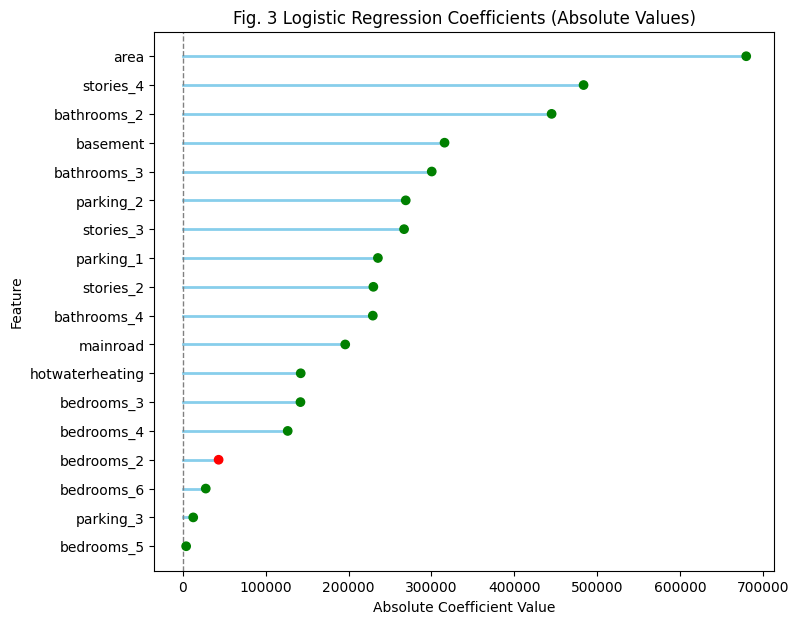

In [79]:
plot_sorted_coefficients(coef)

Text(0.5, 0.98, 'Fig.4')

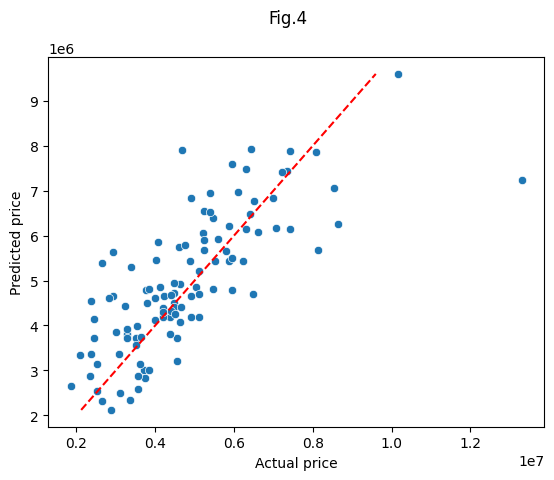

In [80]:
sns.scatterplot(x = y_test, y = y_pred,  alpha = 1)
plt.plot([min(y_pred), max(y_pred)], [min(y_pred), max(y_pred)], linestyle='--', color='red')
plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.suptitle("Fig.4")

### V.ii Ridge Regression

In [81]:
# Performing Ridge Regression
reg = Ridge(alpha = 0.5)  
reg.fit(X_train, y_train)

coef = pd.Series(reg.coef_, index = X.columns)

In [82]:
# Test the regression
y_pred = reg.predict(X_test)

In [83]:
# Compute the rooted mean square error
np.sqrt(mean_squared_error(y_test, y_pred))

1182513.3134725282

In [84]:
#evaluate the model on the predictive set
mean_absolute_error(y_test, y_pred)

842159.4967888591

### V.iii.a - Neural network

In [85]:
# Large Neural Network with three hidden layers ([100,50] neurons)
clf_150_neurons = MLPRegressor(hidden_layer_sizes = (100,50), activation = 'relu',   #jouer avec les couches pour voir
                              solver='adam', max_iter = 6000, alpha = 10, tol = 1e-6, batch_size= 1000,
                              random_state = 666, verbose = True
                              )

# Train the network
clf_150_neurons.fit(X_train, y_train)

# Predict on the test set
y_pred = clf_150_neurons.predict(X_test)

c:\Users\lesli\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:608: UserWarning: Got `batch_size` less than 1 or larger than sample size. It is going to be clipped
  warnings.warn(


Iteration 1, loss = 13146564858977.76562500
Iteration 2, loss = 13146564296182.11523438
Iteration 3, loss = 13146563721805.81640625
Iteration 4, loss = 13146563135223.23632812
Iteration 5, loss = 13146562538032.48828125
Iteration 6, loss = 13146561928930.36718750
Iteration 7, loss = 13146561307981.56640625
Iteration 8, loss = 13146560671793.96484375
Iteration 9, loss = 13146560021896.43164062
Iteration 10, loss = 13146559355609.23437500
Iteration 11, loss = 13146558672384.66796875
Iteration 12, loss = 13146557971241.39453125
Iteration 13, loss = 13146557252799.54882812
Iteration 14, loss = 13146556512365.13281250
Iteration 15, loss = 13146555751594.12695312
Iteration 16, loss = 13146554970291.38671875
Iteration 17, loss = 13146554165296.04492188
Iteration 18, loss = 13146553335387.42968750
Iteration 19, loss = 13146552478566.55273438
Iteration 20, loss = 13146551594065.74023438
Iteration 21, loss = 13146550679935.31054688
Iteration 22, loss = 13146549733698.56054688
Iteration 23, loss 

c:\Users\lesli\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (6000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [87]:
# Compute the rooted mean square error
np.sqrt(mean_squared_error(y_test, y_pred))

1182513.3134725282

In [88]:
#evaluate the model on the predictive set
mean_absolute_error(y_test, y_pred)

842159.4967888591

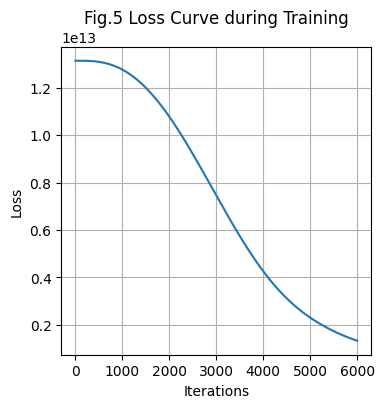

In [89]:
# Plot the loss curve
plt.figure(figsize = (4, 4))
plt.plot(clf_150_neurons.loss_curve_)
plt.title('Fig.5 Loss Curve during Training')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

Text(0.5, 0.98, 'Fig.6')

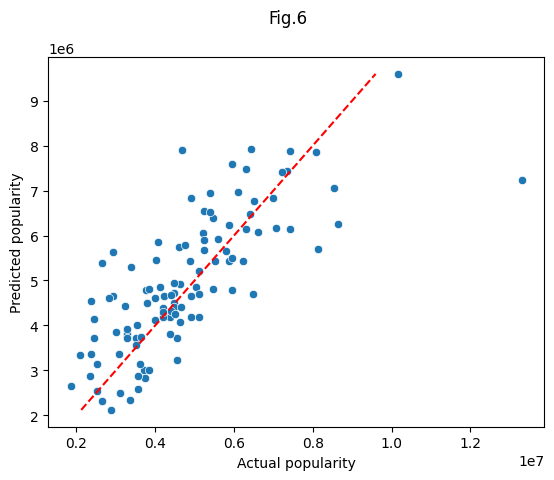

In [90]:
sns.scatterplot(x = y_test, y = y_pred,  alpha = 1)
plt.plot([min(y_pred), max(y_pred)], [min(y_pred), max(y_pred)], linestyle='--', color='red')
plt.xlabel("Actual popularity")
plt.ylabel("Predicted popularity")
plt.suptitle("Fig.6")

### V.iii.b - Neural network

In [91]:
# Large Neural Network with three hidden layers ([100,50] neurons)
clf_150_neurons = MLPRegressor(hidden_layer_sizes = (100,50,100,10), activation = 'relu',   #jouer avec les couches pour voir
                              solver='adam', max_iter = 6000, alpha = 10, tol = 1e-6, batch_size= 1000,
                              random_state = 666, verbose = True
                              )

# Train the network
clf_150_neurons.fit(X_train, y_train)

# Predict on the test set
y_pred = clf_150_neurons.predict(X_test)

c:\Users\lesli\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:608: UserWarning: Got `batch_size` less than 1 or larger than sample size. It is going to be clipped
  warnings.warn(


Iteration 1, loss = 13146564958597.21484375
Iteration 2, loss = 13146564823508.52734375
Iteration 3, loss = 13146564636319.52734375
Iteration 4, loss = 13146564395366.20898438
Iteration 5, loss = 13146564112636.14648438
Iteration 6, loss = 13146563798339.04882812
Iteration 7, loss = 13146563459087.35742188
Iteration 8, loss = 13146563100002.69531250
Iteration 9, loss = 13146562715804.03515625
Iteration 10, loss = 13146562304844.48828125
Iteration 11, loss = 13146561861646.60351562
Iteration 12, loss = 13146561385483.92187500
Iteration 13, loss = 13146560867862.75976562
Iteration 14, loss = 13146560300982.67578125
Iteration 15, loss = 13146559682007.28515625
Iteration 16, loss = 13146559005133.41796875
Iteration 17, loss = 13146558268487.72851562
Iteration 18, loss = 13146557464834.68750000
Iteration 19, loss = 13146556586919.23242188
Iteration 20, loss = 13146555633636.35742188
Iteration 21, loss = 13146554598724.80664062
Iteration 22, loss = 13146553475026.09375000
Iteration 23, loss 

c:\Users\lesli\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (6000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [93]:
# Compute the rooted mean square error
np.sqrt(mean_squared_error(y_test, y_pred))

1182513.3134725282

In [94]:
#evaluate the model on the predictive set
mean_absolute_error(y_test, y_pred)

842159.4967888591

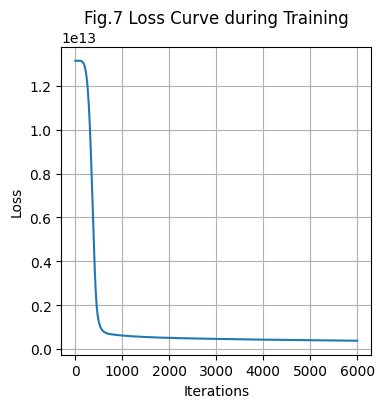

In [95]:
# Plot the loss curve
plt.figure(figsize = (4, 4))
plt.plot(clf_150_neurons.loss_curve_)
plt.title('Fig.7 Loss Curve during Training')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

Text(0.5, 0.98, 'Fig.8')

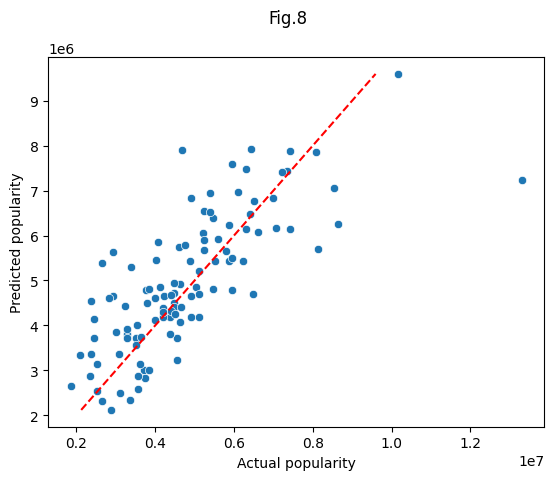

In [96]:
sns.scatterplot(x = y_test, y = y_pred,  alpha = 1)
plt.plot([min(y_pred), max(y_pred)], [min(y_pred), max(y_pred)], linestyle='--', color='red')
plt.xlabel("Actual popularity")
plt.ylabel("Predicted popularity")
plt.suptitle("Fig.8")

### V.iii.c - Neural network

In [97]:
# Large Neural Network with three hidden layers ([100,50] neurons)
clf_150_neurons = MLPRegressor(hidden_layer_sizes = (100,50,100,10), activation = 'relu',   #jouer avec les couches pour voir
                              solver='adam', max_iter = 8000, alpha = 10, tol = 1e-3, batch_size= 5000,
                              random_state = 666, verbose = True
                              )

# Train the network
clf_150_neurons.fit(X_train, y_train)

# Predict on the test set
y_pred = clf_150_neurons.predict(X_test)

# Predict on the training set
y_pred_train = clf_150_neurons.predict(X_train)

c:\Users\lesli\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:608: UserWarning: Got `batch_size` less than 1 or larger than sample size. It is going to be clipped
  warnings.warn(


Iteration 1, loss = 13146564958597.21484375
Iteration 2, loss = 13146564823508.52734375
Iteration 3, loss = 13146564636319.52734375
Iteration 4, loss = 13146564395366.20898438
Iteration 5, loss = 13146564112636.14648438
Iteration 6, loss = 13146563798339.04882812
Iteration 7, loss = 13146563459087.35742188
Iteration 8, loss = 13146563100002.69531250
Iteration 9, loss = 13146562715804.03515625
Iteration 10, loss = 13146562304844.48828125
Iteration 11, loss = 13146561861646.60351562
Iteration 12, loss = 13146561385483.92187500
Iteration 13, loss = 13146560867862.75976562
Iteration 14, loss = 13146560300982.67578125
Iteration 15, loss = 13146559682007.28515625
Iteration 16, loss = 13146559005133.41796875
Iteration 17, loss = 13146558268487.72851562
Iteration 18, loss = 13146557464834.68750000
Iteration 19, loss = 13146556586919.23242188
Iteration 20, loss = 13146555633636.35742188
Iteration 21, loss = 13146554598724.80664062
Iteration 22, loss = 13146553475026.09375000
Iteration 23, loss 

c:\Users\lesli\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (8000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [99]:
# Compute the rooted mean square error
np.sqrt(mean_squared_error(y_test, y_pred))

1182513.3134725282

In [100]:
#evaluate the model on the predictive set
mean_absolute_error(y_test, y_pred)

842159.4967888591

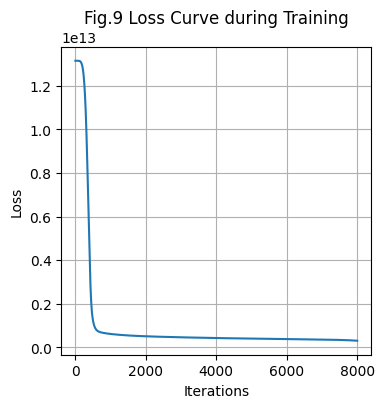

In [101]:
# Plot the loss curve
plt.figure(figsize = (4, 4))
plt.plot(clf_150_neurons.loss_curve_)
plt.title('Fig.9 Loss Curve during Training')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

Text(0.5, 0.98, 'Fig.10')

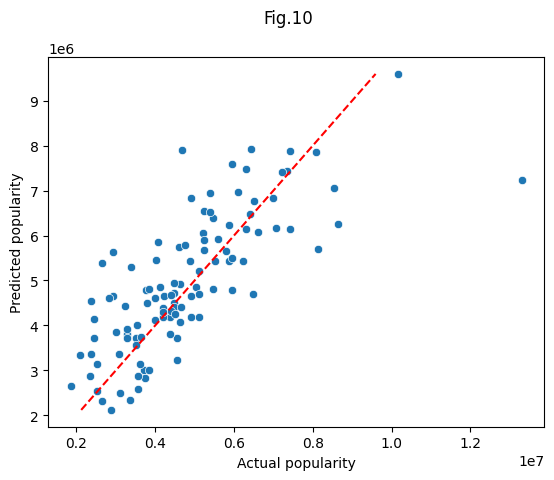

In [102]:
sns.scatterplot(x = y_test, y = y_pred,  alpha = 1)
plt.plot([min(y_pred), max(y_pred)], [min(y_pred), max(y_pred)], linestyle='--', color='red')
plt.xlabel("Actual popularity")
plt.ylabel("Predicted popularity")
plt.suptitle("Fig.10")

# VI - Conclusion

In conclusion, linear regression is the least effective (RMSE=1182782.87565). Regression with regularisation and all our neural networks predict with the same accuracy (RMSE=1182513.31347). The scatterplots of these models (Fig.10, for example) show that the points are well distributed around the line, but that the noise is still significant. Since the fastest model is regression with regularisation, we conclude that this is the best model for achieving our objective.